## prosperity 4 round 2 manual trading challenge
### optimal speed allocation via monte carlo simulation

this notebook answers one question: given our model of how 22,127 teams behave, what percentage of our 50,000 xirec budget should we allocate to speed in order to maximise expected pnl?

the speed pillar is the only one that depends on other players' choices. research and scale are deterministic functions of our own allocation. speed, however, is rank-based: our multiplier depends on where we sit relative to everyone else. this makes it a game theory problem, and to solve it we need a generative model of the population's speed choices.

we build two separate data generating processes (dgps):

1. **dgp a (prior beliefs)**: a heuristic mixture model based on intuition about team archetypes
2. **dgp b (empirically calibrated)**: a mixture model where each group's behaviour is derived from the manual pnl distribution observed in round 1, with assumptions about strategic sophistication tied to demonstrated performance

for each dgp we run a large-scale monte carlo simulation and report the expected speed multiplier and expected total pnl at every candidate speed allocation from 1 percent to 50 percent.

### table of contents

1. setup and data loading
2. understanding the pnl formula
3. population segmentation from round 1 leaderboard
4. dgp a: prior-belief mixture model
5. dgp b: empirically calibrated mixture model
6. monte carlo engine
7. results for dgp a
8. results for dgp b
9. sensitivity analysis
10. limitations and confidence assessment

### 1. setup and data loading

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)
pd.set_option('display.float_format', '{:.2f}'.format)

# load the round 1 manual trading leaderboard
df = pd.read_csv(r"C:\Users\Hassa\OneDrive - Loughborough University\current\IMC Trading - Prosperity 4\Round 2\manual_trading_rankings.csv")
print(f"total teams in leaderboard: {len(df)}")
print(f"unique manual pnl values: {df['manual_pnl'].nunique()}")
print()
print(df['manual_pnl'].describe())

total teams in leaderboard: 22127
unique manual pnl values: 311

count      22127.00
mean       13725.22
std        47598.65
min     -3507500.00
25%            0.00
50%            0.00
75%            0.00
max        87995.00
Name: manual_pnl, dtype: float64


### 2. understanding the pnl formula

the manual challenge asks us to split 50,000 xirecs across three pillars: research, scale, and speed. each pillar takes a percentage (0 to 100), and the total cannot exceed 100 percent.

the gross pnl is the product of three outputs:

- **research(x)** = 200,000 * ln(1 + x) / ln(1 + 100), where x is the percentage allocated. this is a concave logarithmic function that saturates quickly. going from 0 to 30 percent captures most of the value.
- **scale(x)** = 7 * x / 100, a simple linear function. every percentage point adds 0.07 to the multiplier.
- **speed multiplier** is rank-based across all active participants. the team with the highest speed allocation gets 0.9, the lowest gets 0.1, and everyone in between is linearly interpolated by rank. ties share the same rank.

the net pnl is:

pnl = research(r) * scale(s) * speed_multiplier - budget_used

where budget_used = (r + s + speed_pct) / 100 * 50,000.

the key tension: research and scale are under our control, but speed depends on the entire population. we need to model the population to optimise our allocation.

In [4]:
# define the three pillar functions

def research_output(x):
    '''logarithmic research output. x is percentage (0-100).'''
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale_output(x):
    '''linear scale output. x is percentage (0-100).'''
    return 7 * x / 100

def speed_multiplier_from_rank(our_rank, total_teams):
    '''
    compute the speed multiplier given our rank among total_teams.
    rank 1 = highest allocation = 0.9 multiplier.
    rank total_teams = lowest allocation = 0.1 multiplier.
    linear interpolation in between.
    '''
    if total_teams == 1:
        return 0.9
    return 0.9 - (our_rank - 1) / (total_teams - 1) * 0.8

def compute_pnl(research_pct, scale_pct, speed_multiplier, total_pct_used=None):
    '''compute net pnl given allocations and speed multiplier.'''
    if total_pct_used is None:
        total_pct_used = research_pct + scale_pct
    r = research_output(research_pct)
    s = scale_output(scale_pct)
    budget_used = total_pct_used / 100 * 50_000
    return r * s * speed_multiplier - budget_used

# sanity check: research saturates quickly, scale is linear
print("research output at various allocations:")
for x in [5, 10, 20, 30, 50, 70, 90]:
    print(f"  {x}% -> {research_output(x):.0f} (captures {research_output(x)/research_output(100)*100:.0f}% of max)")
print()
print("scale output at various allocations:")
for x in [10, 30, 50, 70, 90]:
    print(f"  {x}% -> {scale_output(x):.2f}")

research output at various allocations:
  5% -> 77647 (captures 39% of max)
  10% -> 103915 (captures 52% of max)
  20% -> 131937 (captures 66% of max)
  30% -> 148815 (captures 74% of max)
  50% -> 170389 (captures 85% of max)
  70% -> 184727 (captures 92% of max)
  90% -> 195482 (captures 98% of max)

scale output at various allocations:
  10% -> 0.70
  30% -> 2.10
  50% -> 3.50
  70% -> 4.90
  90% -> 6.30


### 3. population segmentation from round 1 leaderboard

we segment the 22,127 teams into groups based on their round 1 manual pnl. the round 1 manual challenge was an auction problem, so the pnl achieved is a reasonable proxy for strategic sophistication and engagement level.

critically, teams with pnl = 0 are classified as disengaged and removed from the active participant count. these teams did not submit a manual trade and will almost certainly not submit a meaningful speed allocation either. removing them is essential because the speed multiplier depends on rank among *active* participants, not the total registered population.

In [5]:
# segment teams by manual pnl using dgp b boundaries

elite = df[(df['manual_pnl'] > 56300) & (df['manual_pnl'] <= 87995)]
non_optimal = df[(df['manual_pnl'] >= 24500) & (df['manual_pnl'] <= 56300)]
pos_noise = df[(df['manual_pnl'] > 0) & (df['manual_pnl'] < 24500)]
disengaged = df[df['manual_pnl'] == 0]
neg_noise = df[(df['manual_pnl'] < 0) & (df['manual_pnl'] > -40000)]
loss_max = df[df['manual_pnl'] <= -40000]

n_elite = len(elite)
n_non_optimal = len(non_optimal)
n_pos_noise = len(pos_noise)
n_disengaged = len(disengaged)
n_neg_noise = len(neg_noise)
n_loss_max = len(loss_max)
n_total = len(df)
n_active = n_total - n_disengaged

print("population segmentation")
print(f"  elite         (56300 < pnl <= 87995):  {n_elite:>6}  ({n_elite/n_total*100:.1f}%)")
print(f"  non-optimal   (24500 <= pnl <= 56300): {n_non_optimal:>6}  ({n_non_optimal/n_total*100:.1f}%)")
print(f"  +pnl noise    (0 < pnl < 24500):       {n_pos_noise:>6}  ({n_pos_noise/n_total*100:.1f}%)")
print(f"  disengaged    (pnl = 0):               {n_disengaged:>6}  ({n_disengaged/n_total*100:.1f}%)")
print(f"  -pnl noise    (-40000 < pnl < 0):      {n_neg_noise:>6}  ({n_neg_noise/n_total*100:.1f}%)")
print(f"  loss maximizer(pnl <= -40000):          {n_loss_max:>6}  ({n_loss_max/n_total*100:.1f}%)")
print(f"  total:                                  {n_total:>6}")
print(f"  active (excl. disengaged):              {n_active:>6}")
print()
print(f"the active population ({n_active} teams) is dominated by the elite group")
print(f"({n_elite} teams = {n_elite/n_active*100:.0f}% of active). this is the group whose")
print(f"behaviour most impacts our speed multiplier.")

population segmentation
  elite         (56300 < pnl <= 87995):    3395  (15.3%)
  non-optimal   (24500 <= pnl <= 56300):    911  (4.1%)
  +pnl noise    (0 < pnl < 24500):          231  (1.0%)
  disengaged    (pnl = 0):                17325  (78.3%)
  -pnl noise    (-40000 < pnl < 0):         103  (0.5%)
  loss maximizer(pnl <= -40000):             162  (0.7%)
  total:                                   22127
  active (excl. disengaged):                4802

the active population (4802 teams) is dominated by the elite group
(3395 teams = 71% of active). this is the group whose
behaviour most impacts our speed multiplier.


### 4. dgp a: prior-belief mixture model

this is our first attempt at modelling population behaviour. it uses broad heuristic categories and uniform/normal mixture components. the groups here are defined by global leaderboard position (top 15% = elite) rather than pnl thresholds.

**elite (top 15% of active, ~720 teams):**
3-component uniform mixture. 30% choose uniform(0, 15), 50% choose uniform(15, 50), 20% choose uniform(50, 80). this models a wide range of sophistication within the top tier.

**non-optimal (remaining positive pnl):**
4-component mixture. 25% equal-splitters uniform(25, 40), 25% research-oriented uniform(0, 20), 25% risk-averse high-speed uniform(60, 100), 25% pure noise normal(50, 25).

**trolling (negative pnl):**
3-component mixture. 40% chaos-maximisers uniform(80, 100), 30% zero allocation, 30% uniformly random.

In [6]:
def sample_speed_dgp_a(n_active, rng=None):
    '''
    sample speed allocations for all active teams under dgp a.
    uses position-based grouping (top 15% = elite).
    '''
    if rng is None:
        rng = np.random.default_rng()
    
    n_positive = n_elite + n_non_optimal + n_pos_noise
    n_negative = n_neg_noise + n_loss_max
    n_elite_a = int(0.15 * n_active)
    n_non_opt_a = n_positive - n_elite_a
    n_troll_a = n_negative
    remainder = n_active - n_elite_a - n_non_opt_a - n_troll_a
    n_non_opt_a += remainder
    
    allocations = []
    
    # elite: wide spread, centred around 15-50%
    for _ in range(n_elite_a):
        r = rng.random()
        if r < 0.30:
            allocations.append(rng.uniform(0, 15))
        elif r < 0.80:
            allocations.append(rng.uniform(15, 50))
        else:
            allocations.append(rng.uniform(50, 80))
    
    # non-optimal: very spread out
    for _ in range(n_non_opt_a):
        r = rng.random()
        if r < 0.25:
            allocations.append(rng.uniform(25, 40))
        elif r < 0.50:
            allocations.append(rng.uniform(0, 20))
        elif r < 0.75:
            allocations.append(rng.uniform(60, 100))
        else:
            allocations.append(np.clip(rng.normal(50, 25), 0, 100))
    
    # trolling: bimodal at 0 and 80-100
    for _ in range(n_troll_a):
        r = rng.random()
        if r < 0.40:
            allocations.append(rng.uniform(80, 100))
        elif r < 0.70:
            allocations.append(0.0)
        else:
            allocations.append(rng.uniform(0, 100))
    
    return np.array(allocations)

test_a = sample_speed_dgp_a(n_active)
print(f"dgp a sample: mean={test_a.mean():.1f}%, median={np.median(test_a):.1f}%")

dgp a sample: mean=41.6%, median=35.1%


### 5. dgp b: empirically calibrated mixture model

this is our primary model. group membership is determined by observed round 1 manual pnl, and behavioural assumptions reflect each group's likely strategic sophistication.

**elite group (3,395 teams, pnl > 56,300):**
these teams solved round 1 optimally. the key question is what speed allocation they would compute as optimal. the answer depends on what they think everyone else will do, creating a recursive game theory problem. however, the math clearly shows that research and scale should be prioritised (research is logarithmic, scale is linear, both have high marginal value at low allocations). we model elite teams as concentrating at low speed: 40% choose uniform(2, 10), 35% choose uniform(8, 20), 15% choose uniform(15, 35), 10% choose uniform(0, 5).

**non-optimal group (911 teams):**
wider spread, centred higher. 25% uniform(10, 30), 25% uniform(25, 45), 25% uniform(5, 20), 25% uniform(30, 60).

**+pnl noise group (231 teams):**
near-random with slight positive skew. 30% uniform(20, 50), 30% uniform(0, 30), 20% uniform(30, 70), 20% normal(33, 15).

**-pnl noise group (103 teams):**
slightly negative skew. 30% uniform(50, 100), 30% uniform(0, 10), 40% uniform(0, 100).

**loss maximiser group (162 teams):**
extreme allocations. 50% uniform(80, 100), 30% zero, 20% uniform(90, 100).

dgp b sample: mean=17.7%, median=12.2%


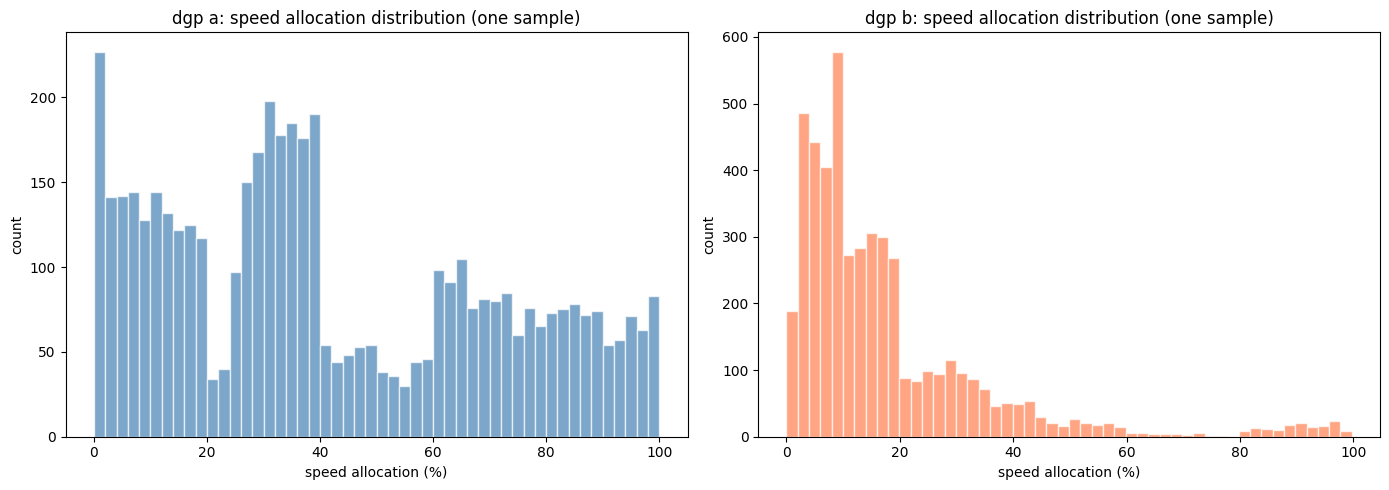

In [7]:
def sample_speed_dgp_b(n_active, rng=None):
    '''
    sample speed allocations for all active teams under dgp b.
    uses pnl-based grouping with empirically calibrated mixture components.
    '''
    if rng is None:
        rng = np.random.default_rng()
    
    allocations = []
    
    # elite: concentrated at low speed (2-20% mostly)
    for _ in range(n_elite):
        r = rng.random()
        if r < 0.40:
            allocations.append(rng.uniform(2, 10))
        elif r < 0.75:
            allocations.append(rng.uniform(8, 20))
        elif r < 0.90:
            allocations.append(rng.uniform(15, 35))
        else:
            allocations.append(rng.uniform(0, 5))
    
    # non-optimal: wider spread, centred around 20-40%
    for _ in range(n_non_optimal):
        r = rng.random()
        if r < 0.25:
            allocations.append(rng.uniform(10, 30))
        elif r < 0.50:
            allocations.append(rng.uniform(25, 45))
        elif r < 0.75:
            allocations.append(rng.uniform(5, 20))
        else:
            allocations.append(rng.uniform(30, 60))
    
    # +pnl noise: near random, slight positive skew
    for _ in range(n_pos_noise):
        r = rng.random()
        if r < 0.30:
            allocations.append(rng.uniform(20, 50))
        elif r < 0.60:
            allocations.append(rng.uniform(0, 30))
        elif r < 0.80:
            allocations.append(rng.uniform(30, 70))
        else:
            allocations.append(np.clip(rng.normal(33, 15), 0, 100))
    
    # -pnl noise: slight negative skew
    for _ in range(n_neg_noise):
        r = rng.random()
        if r < 0.30:
            allocations.append(rng.uniform(50, 100))
        elif r < 0.60:
            allocations.append(rng.uniform(0, 10))
        else:
            allocations.append(rng.uniform(0, 100))
    
    # loss maximiser: extreme allocations
    for _ in range(n_loss_max):
        r = rng.random()
        if r < 0.50:
            allocations.append(rng.uniform(80, 100))
        elif r < 0.80:
            allocations.append(0.0)
        else:
            allocations.append(rng.uniform(90, 100))
    
    return np.array(allocations)

test_b = sample_speed_dgp_b(n_active)
print(f"dgp b sample: mean={test_b.mean():.1f}%, median={np.median(test_b):.1f}%")

# visualise both dgps side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(test_a, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].set_title('dgp a: speed allocation distribution (one sample)')
axes[0].set_xlabel('speed allocation (%)')
axes[0].set_ylabel('count')

axes[1].hist(test_b, bins=50, alpha=0.7, color='coral', edgecolor='white')
axes[1].set_title('dgp b: speed allocation distribution (one sample)')
axes[1].set_xlabel('speed allocation (%)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

### 6. monte carlo engine

the simulation works as follows for each trial:

1. sample speed allocations for all active teams from the chosen dgp
2. for each candidate speed allocation that we might choose, insert our allocation into the population, compute our rank (handling ties), look up our speed multiplier, find our optimal research/scale split for the remaining budget, and compute our net pnl
3. average across all trials to get expected multiplier and expected pnl

**key optimisation insight**: since we always use the full 100% budget (there is no benefit to saving), budget_used = 50,000 regardless of how we split. this means we maximise research(r) * scale(100 - speed - r) * multiplier. for each fixed speed allocation, the optimal research/scale split is a simple 1d problem that we pre-compute.

In [8]:
def optimal_research_scale_split(speed_pct):
    '''
    given a fixed speed allocation, find research % that maximises
    research(r) * scale(100 - speed_pct - r).
    searches at 0.1% resolution.
    '''
    remaining = 100 - speed_pct
    best_val, best_r = -np.inf, 0
    for r_10 in range(0, int(remaining * 10) + 1):
        r = r_10 / 10
        s = remaining - r
        if s < 0: break
        val = research_output(r) * scale_output(s)
        if val > best_val:
            best_val, best_r = val, r
    return best_r, remaining - best_r, best_val

# show optimal splits at key speed allocations
print("for each speed allocation, the optimal research/scale split and resulting product:")
print(f"{'speed':>6} {'research':>10} {'scale':>8} {'r*s product':>12} {'vs speed=0':>10}")
base = optimal_research_scale_split(0)[2]
for sp in [0, 1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
    r, s, v = optimal_research_scale_split(sp)
    print(f"{sp:>5}% {r:>9.1f}% {s:>7.1f}% {v:>11.0f} {v/base*100:>9.0f}%")

for each speed allocation, the optimal research/scale split and resulting product:
 speed   research    scale  r*s product vs speed=0
    0%      23.1%    76.9%      742336       100%
    1%      22.9%    76.1%      732689        99%
    2%      22.8%    75.2%      723068        97%
    5%      22.2%    72.8%      694352        94%
   10%      21.2%    68.8%      647006        87%
   15%      20.2%    64.8%      600329        81%
   20%      19.2%    60.8%      554360        75%
   25%      18.2%    56.8%      509140        69%
   30%      17.2%    52.8%      464718        63%
   35%      16.2%    48.8%      421147        57%
   40%      15.1%    44.9%      378488        51%
   45%      14.1%    40.9%      336813        45%
   50%      13.0%    37.0%      296207        40%


In [10]:
def run_monte_carlo(dgp_sampler, n_active, candidate_speeds, n_trials=5000):
    '''
    run the full monte carlo simulation.
    
    for each trial, sample all teams' speed allocations from the dgp,
    then for each candidate speed allocation compute our rank, multiplier,
    and resulting pnl using the pre-computed optimal research/scale split.
    '''
    n_candidates = len(candidate_speeds)
    
    # pre-compute optimal research/scale for each candidate
    optimal_splits = {}
    for sp in candidate_speeds:
        r, s, rs_product = optimal_research_scale_split(sp)
        optimal_splits[sp] = (r, s, rs_product)
    
    all_multipliers = np.zeros((n_trials, n_candidates))
    all_pnls = np.zeros((n_trials, n_candidates))
    all_ranks = np.zeros((n_trials, n_candidates))
    
    for trial in range(n_trials):
        if trial % 1000 == 0:
            print(f"  trial {trial}/{n_trials}")
        rng = np.random.default_rng(trial)
        pop_speeds = dgp_sampler(n_active, rng=rng)
        
        for j, sp in enumerate(candidate_speeds):
            # compute our rank: how many teams allocated strictly more than us?
            all_speeds = np.append(pop_speeds, sp)
            n_above = np.sum(all_speeds > sp)
            our_rank = n_above + 1
            n_total = len(all_speeds)
            mult = speed_multiplier_from_rank(our_rank, n_total)
            
            _, _, rs_product = optimal_splits[sp]
            pnl = rs_product * mult - 50_000
            
            all_multipliers[trial, j] = mult
            all_pnls[trial, j] = pnl
            all_ranks[trial, j] = our_rank
    
    print(f"  done. {n_trials} trials completed.")
    
    return {
        'candidate_speeds': candidate_speeds,
        'expected_multiplier': all_multipliers.mean(axis=0),
        'expected_pnl': all_pnls.mean(axis=0),
        'multiplier_std': all_multipliers.std(axis=0),
        'pnl_std': all_pnls.std(axis=0),
        'pnl_p5': np.percentile(all_pnls, 5, axis=0),
        'pnl_p25': np.percentile(all_pnls, 25, axis=0),
        'pnl_p75': np.percentile(all_pnls, 75, axis=0),
        'pnl_p95': np.percentile(all_pnls, 95, axis=0),
        'expected_rank': all_ranks.mean(axis=0),
        'rank_std': all_ranks.std(axis=0),
        'all_multipliers': all_multipliers,
        'all_pnls': all_pnls,
    }

print("monte carlo engine defined")

monte carlo engine defined


### 7. results for dgp a

running 5,000 trials with the prior-belief mixture model. we search from 1% to 50% speed allocation.

In [11]:
candidate_speeds = list(range(1, 51))

print("running monte carlo for dgp a...")
results_a = run_monte_carlo(sample_speed_dgp_a, n_active, candidate_speeds, n_trials=5000)

# find optimal
best_idx_a = np.argmax(results_a['expected_pnl'])
best_sp_a = candidate_speeds[best_idx_a]

# display summary table (every 2%)
print()
print(f"{'speed':>6} {'e[mult]':>8} {'e[pnl]':>10} {'std[pnl]':>10} {'p5[pnl]':>10} {'p95[pnl]':>10}")
for i, sp in enumerate(candidate_speeds):
    if sp <= 25 or sp % 5 == 0:
        marker = " <-- optimal" if sp == best_sp_a else ""
        print(f"{sp:>5}% {results_a['expected_multiplier'][i]:>8.4f} "
              f"{results_a['expected_pnl'][i]:>10.0f} "
              f"{results_a['pnl_std'][i]:>10.0f} "
              f"{results_a['pnl_p5'][i]:>10.0f} "
              f"{results_a['pnl_p95'][i]:>10.0f}{marker}")

print(f"\noptimal speed under dgp a: {best_sp_a}%")
print(f"expected pnl: {results_a['expected_pnl'][best_idx_a]:.0f}")
r_opt, s_opt, _ = optimal_research_scale_split(best_sp_a)
print(f"optimal full allocation: research={r_opt:.1f}%, scale={s_opt:.1f}%, speed={best_sp_a}%")

running monte carlo for dgp a...
  trial 0/5000
  trial 1000/5000
  trial 2000/5000
  trial 3000/5000
  trial 4000/5000
  done. 5000 trials completed.

 speed  e[mult]     e[pnl]   std[pnl]    p5[pnl]   p95[pnl]
    1%   0.1277      43544       1454      41212      45973
    2%   0.1386      50193       1728      47363      53024
    3%   0.1495      56629       1931      53559      59858
    4%   0.1604      62882       2090      59440      66242
    5%   0.1713      68947       2238      65359      72647
    6%   0.1823      74846       2367      70965      78723
    7%   0.1933      80570       2458      76488      84701
    8%   0.2044      86130       2565      81814      90467
    9%   0.2156      91514       2639      87163      95911
   10%   0.2267      96699       2697      92201     101148
   11%   0.2379     101712       2754      97042     106284
   12%   0.2492     106561       2786     101895     111106
   13%   0.2605     111229       2826     106650     115826
   14%  

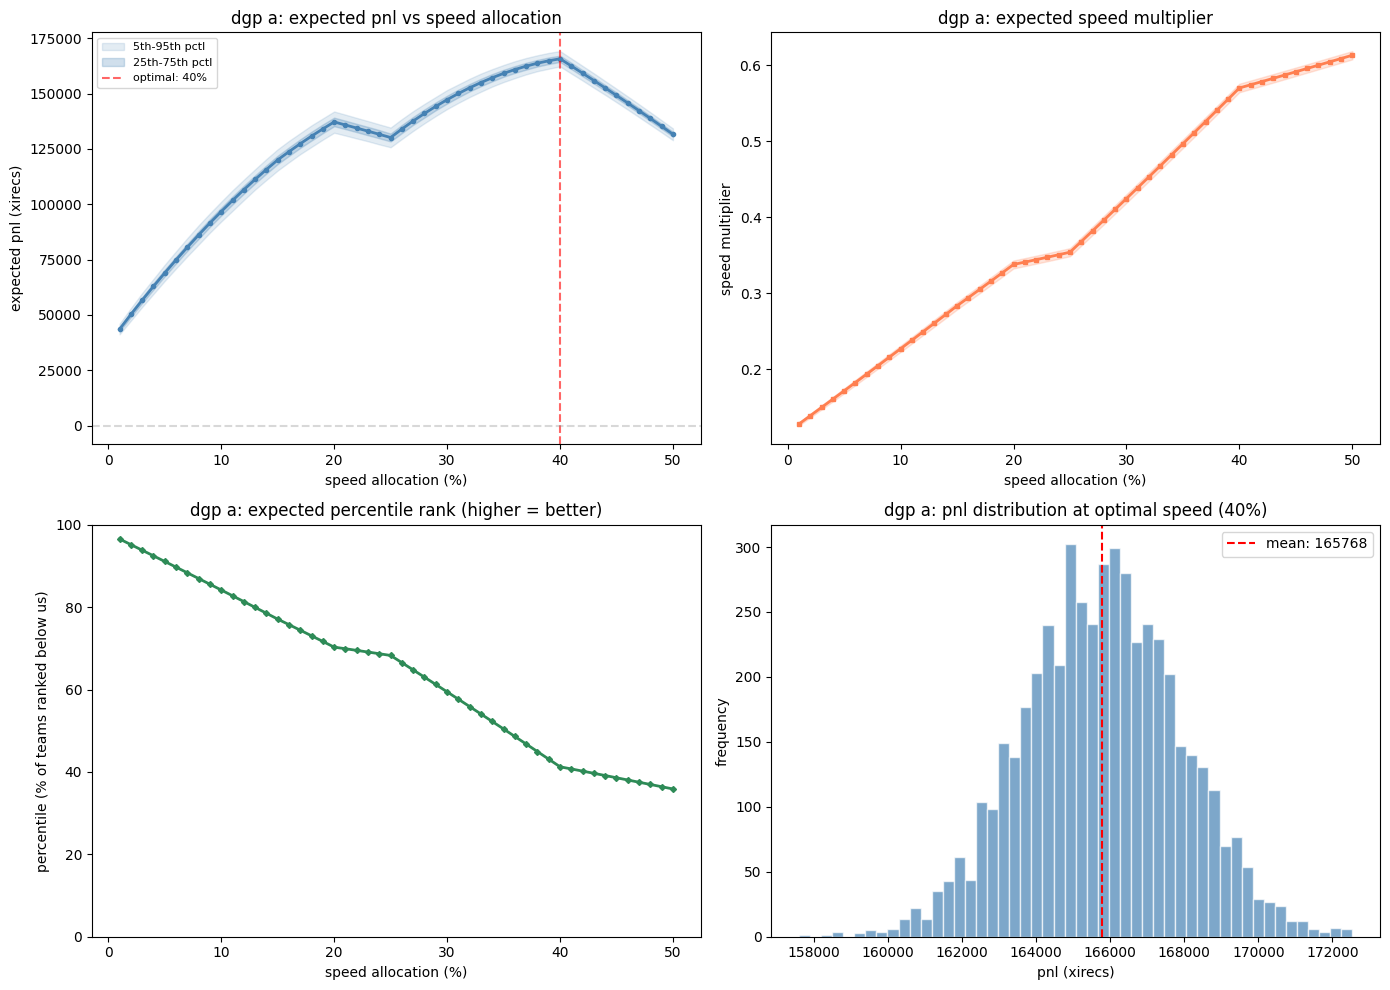

In [12]:
# visualise dgp a results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(candidate_speeds, results_a['expected_pnl'], 'o-', color='steelblue',
                linewidth=2, markersize=3)
axes[0, 0].fill_between(candidate_speeds, results_a['pnl_p5'], results_a['pnl_p95'],
                         alpha=0.15, color='steelblue', label='5th-95th pctl')
axes[0, 0].fill_between(candidate_speeds, results_a['pnl_p25'], results_a['pnl_p75'],
                         alpha=0.25, color='steelblue', label='25th-75th pctl')
axes[0, 0].axvline(x=best_sp_a, color='red', linestyle='--', alpha=0.6, label=f'optimal: {best_sp_a}%')
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0, 0].set_title('dgp a: expected pnl vs speed allocation')
axes[0, 0].set_xlabel('speed allocation (%)')
axes[0, 0].set_ylabel('expected pnl (xirecs)')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(candidate_speeds, results_a['expected_multiplier'], 's-', color='coral',
                linewidth=2, markersize=3)
axes[0, 1].fill_between(candidate_speeds,
                         results_a['expected_multiplier'] - results_a['multiplier_std'],
                         results_a['expected_multiplier'] + results_a['multiplier_std'],
                         alpha=0.2, color='coral')
axes[0, 1].set_title('dgp a: expected speed multiplier')
axes[0, 1].set_xlabel('speed allocation (%)')
axes[0, 1].set_ylabel('speed multiplier')

axes[1, 0].plot(candidate_speeds, results_a['expected_rank']/n_active*100, 'D-',
                color='seagreen', linewidth=2, markersize=3)
axes[1, 0].set_title('dgp a: expected percentile rank (higher = better)')
axes[1, 0].set_xlabel('speed allocation (%)')
axes[1, 0].set_ylabel('percentile (% of teams ranked below us)')
axes[1, 0].set_ylim(0, 100)

axes[1, 1].hist(results_a['all_pnls'][:, best_idx_a], bins=50, alpha=0.7,
                color='steelblue', edgecolor='white')
axes[1, 1].axvline(x=results_a['expected_pnl'][best_idx_a], color='red',
                   linestyle='--', label=f'mean: {results_a["expected_pnl"][best_idx_a]:.0f}')
axes[1, 1].set_title(f'dgp a: pnl distribution at optimal speed ({best_sp_a}%)')
axes[1, 1].set_xlabel('pnl (xirecs)')
axes[1, 1].set_ylabel('frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 8. results for dgp b

now running the empirically calibrated model. since the elite group (70% of active teams) is modelled as concentrating at low speed allocations, the optimal allocation should be different from dgp a.

In [13]:
print("running monte carlo for dgp b...")
results_b = run_monte_carlo(sample_speed_dgp_b, n_active, candidate_speeds, n_trials=5000)

best_idx_b = np.argmax(results_b['expected_pnl'])
best_sp_b = candidate_speeds[best_idx_b]

print()
print(f"{'speed':>6} {'e[mult]':>8} {'e[pnl]':>10} {'std[pnl]':>10} {'p5[pnl]':>10} {'p95[pnl]':>10}")
for i, sp in enumerate(candidate_speeds):
    if sp <= 25 or sp % 5 == 0:
        marker = " <-- optimal" if sp == best_sp_b else ""
        print(f"{sp:>5}% {results_b['expected_multiplier'][i]:>8.4f} "
              f"{results_b['expected_pnl'][i]:>10.0f} "
              f"{results_b['pnl_std'][i]:>10.0f} "
              f"{results_b['pnl_p5'][i]:>10.0f} "
              f"{results_b['pnl_p95'][i]:>10.0f}{marker}")

print(f"\noptimal speed under dgp b: {best_sp_b}%")
print(f"expected pnl: {results_b['expected_pnl'][best_idx_b]:.0f}")
r_opt, s_opt, _ = optimal_research_scale_split(best_sp_b)
print(f"optimal full allocation: research={r_opt:.1f}%, scale={s_opt:.1f}%, speed={best_sp_b}%")

running monte carlo for dgp b...
  trial 0/5000
  trial 1000/5000
  trial 2000/5000
  trial 3000/5000
  trial 4000/5000
  done. 5000 trials completed.

 speed  e[mult]     e[pnl]   std[pnl]    p5[pnl]   p95[pnl]
    1%   0.1205      38297       1250      36330      40358
    2%   0.1328      46032       1580      43508      48688
    3%   0.1734      73721       2350      69843      77688
    4%   0.2139     100588       2770      96028     105057
    5%   0.2546     126753       3073     121810     131873
    6%   0.2864     146112       3238     140903     151519
    7%   0.3182     164875       3340     159407     170214
    8%   0.3500     183050       3411     177548     188641
    9%   0.3983     211465       3442     205816     217085
   10%   0.4467     239028       3366     233513     244507
   11%   0.4682     248501       3326     242995     254048
   12%   0.4896     257595       3284     252194     262980
   13%   0.5111     266302       3247     261005     271625
   14%  

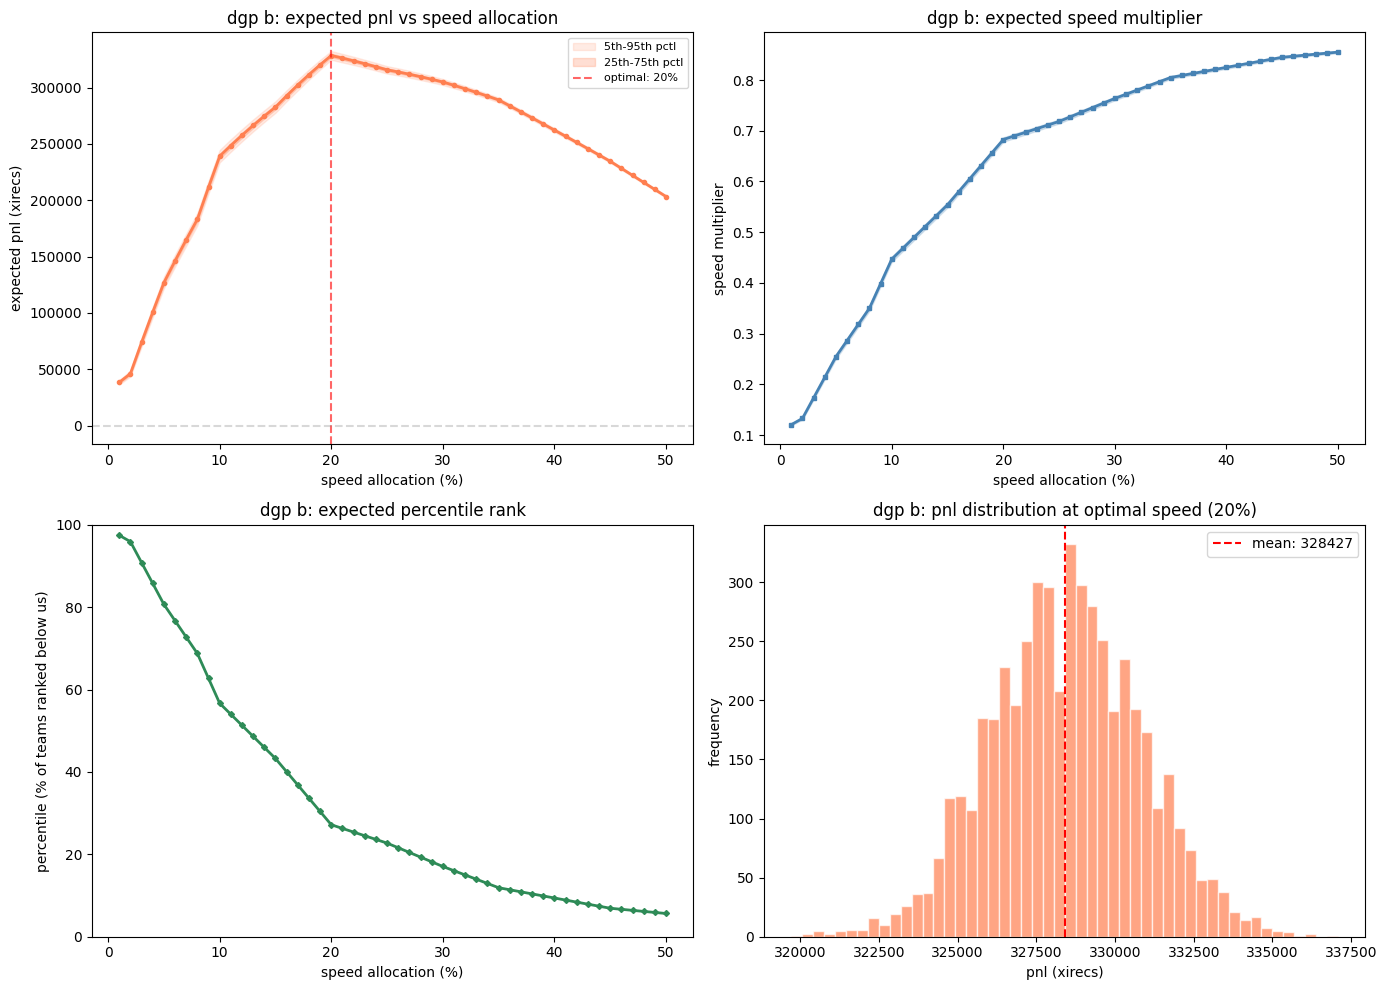

In [14]:
# visualise dgp b results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(candidate_speeds, results_b['expected_pnl'], 'o-', color='coral',
                linewidth=2, markersize=3)
axes[0, 0].fill_between(candidate_speeds, results_b['pnl_p5'], results_b['pnl_p95'],
                         alpha=0.15, color='coral', label='5th-95th pctl')
axes[0, 0].fill_between(candidate_speeds, results_b['pnl_p25'], results_b['pnl_p75'],
                         alpha=0.25, color='coral', label='25th-75th pctl')
axes[0, 0].axvline(x=best_sp_b, color='red', linestyle='--', alpha=0.6, label=f'optimal: {best_sp_b}%')
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0, 0].set_title('dgp b: expected pnl vs speed allocation')
axes[0, 0].set_xlabel('speed allocation (%)')
axes[0, 0].set_ylabel('expected pnl (xirecs)')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(candidate_speeds, results_b['expected_multiplier'], 's-', color='steelblue',
                linewidth=2, markersize=3)
axes[0, 1].fill_between(candidate_speeds,
                         results_b['expected_multiplier'] - results_b['multiplier_std'],
                         results_b['expected_multiplier'] + results_b['multiplier_std'],
                         alpha=0.2, color='steelblue')
axes[0, 1].set_title('dgp b: expected speed multiplier')
axes[0, 1].set_xlabel('speed allocation (%)')
axes[0, 1].set_ylabel('speed multiplier')

axes[1, 0].plot(candidate_speeds, results_b['expected_rank']/n_active*100, 'D-',
                color='seagreen', linewidth=2, markersize=3)
axes[1, 0].set_title('dgp b: expected percentile rank')
axes[1, 0].set_xlabel('speed allocation (%)')
axes[1, 0].set_ylabel('percentile (% of teams ranked below us)')
axes[1, 0].set_ylim(0, 100)

axes[1, 1].hist(results_b['all_pnls'][:, best_idx_b], bins=50, alpha=0.7,
                color='coral', edgecolor='white')
axes[1, 1].axvline(x=results_b['expected_pnl'][best_idx_b], color='red',
                   linestyle='--', label=f'mean: {results_b["expected_pnl"][best_idx_b]:.0f}')
axes[1, 1].set_title(f'dgp b: pnl distribution at optimal speed ({best_sp_b}%)')
axes[1, 1].set_xlabel('pnl (xirecs)')
axes[1, 1].set_ylabel('frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 9. sensitivity analysis

our results depend heavily on the dgp assumptions. we test two perturbations:

1. **aggressive elite**: what if elite teams allocate more to speed (shifted up ~10 percentage points)? this tests our assumption that elite teams will cluster at low speed.
2. **fewer active teams**: what if only 3,000 teams are active instead of 4,802? this tests sensitivity to the disengaged count.

In [15]:
# sensitivity 1: aggressive elite
def sample_speed_dgp_b_aggressive_elite(n_active, rng=None):
    '''dgp b with elite speed shifted up ~10pp.'''
    if rng is None: rng = np.random.default_rng()
    allocations = []
    for _ in range(n_elite):
        r = rng.random()
        if r < 0.40: allocations.append(rng.uniform(10, 25))
        elif r < 0.75: allocations.append(rng.uniform(20, 40))
        elif r < 0.90: allocations.append(rng.uniform(30, 50))
        else: allocations.append(rng.uniform(5, 15))
    for _ in range(n_non_optimal):
        r = rng.random()
        if r < 0.25: allocations.append(rng.uniform(10, 30))
        elif r < 0.50: allocations.append(rng.uniform(25, 45))
        elif r < 0.75: allocations.append(rng.uniform(5, 20))
        else: allocations.append(rng.uniform(30, 60))
    for _ in range(n_pos_noise):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(20, 50))
        elif r < 0.60: allocations.append(rng.uniform(0, 30))
        elif r < 0.80: allocations.append(rng.uniform(30, 70))
        else: allocations.append(np.clip(rng.normal(33, 15), 0, 100))
    for _ in range(n_neg_noise):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(50, 100))
        elif r < 0.60: allocations.append(rng.uniform(0, 10))
        else: allocations.append(rng.uniform(0, 100))
    for _ in range(n_loss_max):
        r = rng.random()
        if r < 0.50: allocations.append(rng.uniform(80, 100))
        elif r < 0.80: allocations.append(0.0)
        else: allocations.append(rng.uniform(90, 100))
    return np.array(allocations)

# sensitivity 2: fewer active teams (proportionally scaled)
def sample_speed_dgp_b_fewer(n_override, rng=None):
    '''dgp b scaled to fewer active teams.'''
    if rng is None: rng = np.random.default_rng()
    ratio = n_override / n_active
    n_e = int(n_elite * ratio)
    n_no = int(n_non_optimal * ratio)
    n_pn = int(n_pos_noise * ratio)
    n_nn = int(n_neg_noise * ratio)
    n_lm = n_override - n_e - n_no - n_pn - n_nn
    allocations = []
    for _ in range(n_e):
        r = rng.random()
        if r < 0.40: allocations.append(rng.uniform(2, 10))
        elif r < 0.75: allocations.append(rng.uniform(8, 20))
        elif r < 0.90: allocations.append(rng.uniform(15, 35))
        else: allocations.append(rng.uniform(0, 5))
    for _ in range(n_no):
        r = rng.random()
        if r < 0.25: allocations.append(rng.uniform(10, 30))
        elif r < 0.50: allocations.append(rng.uniform(25, 45))
        elif r < 0.75: allocations.append(rng.uniform(5, 20))
        else: allocations.append(rng.uniform(30, 60))
    for _ in range(n_pn):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(20, 50))
        elif r < 0.60: allocations.append(rng.uniform(0, 30))
        elif r < 0.80: allocations.append(rng.uniform(30, 70))
        else: allocations.append(np.clip(rng.normal(33, 15), 0, 100))
    for _ in range(n_nn):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(50, 100))
        elif r < 0.60: allocations.append(rng.uniform(0, 10))
        else: allocations.append(rng.uniform(0, 100))
    for _ in range(n_lm):
        r = rng.random()
        if r < 0.50: allocations.append(rng.uniform(80, 100))
        elif r < 0.80: allocations.append(0.0)
        else: allocations.append(rng.uniform(90, 100))
    return np.array(allocations)

print("running sensitivity: aggressive elite (3,000 trials)...")
results_s1 = run_monte_carlo(sample_speed_dgp_b_aggressive_elite, n_active,
                              candidate_speeds, n_trials=3000)
best_s1 = np.argmax(results_s1['expected_pnl'])
print(f"optimal: {candidate_speeds[best_s1]}%, e[pnl]={results_s1['expected_pnl'][best_s1]:.0f}")
print()

print("running sensitivity: fewer active teams (3000) (3,000 trials)...")
results_s2 = run_monte_carlo(
    lambda n, rng=None: sample_speed_dgp_b_fewer(3000, rng=rng),
    3000, candidate_speeds, n_trials=3000)
best_s2 = np.argmax(results_s2['expected_pnl'])
print(f"optimal: {candidate_speeds[best_s2]}%, e[pnl]={results_s2['expected_pnl'][best_s2]:.0f}")

running sensitivity: aggressive elite (3,000 trials)...
  trial 0/3000
  trial 1000/3000
  trial 2000/3000
  done. 3000 trials completed.
optimal: 40%, e[pnl]=246178

running sensitivity: fewer active teams (3000) (3,000 trials)...
  trial 0/3000
  trial 1000/3000
  trial 2000/3000
  done. 3000 trials completed.
optimal: 20%, e[pnl]=328306


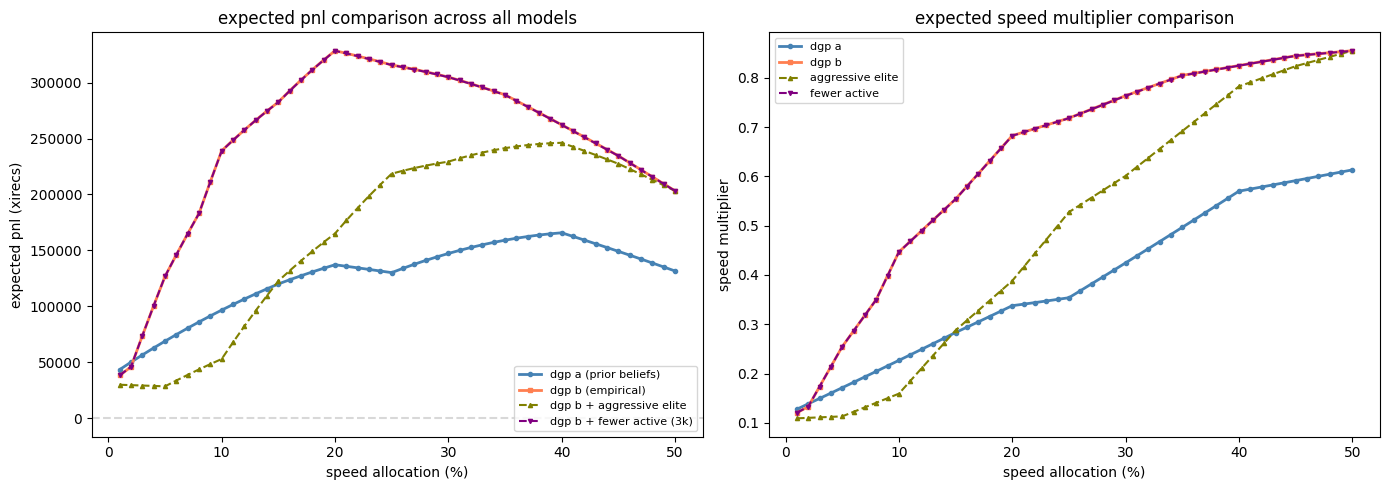

In [16]:
# comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(candidate_speeds, results_a['expected_pnl'], 'o-',
             color='steelblue', linewidth=2, markersize=3, label='dgp a (prior beliefs)')
axes[0].plot(candidate_speeds, results_b['expected_pnl'], 's-',
             color='coral', linewidth=2, markersize=3, label='dgp b (empirical)')
axes[0].plot(candidate_speeds, results_s1['expected_pnl'], '^--',
             color='olive', linewidth=1.5, markersize=3, label='dgp b + aggressive elite')
axes[0].plot(candidate_speeds, results_s2['expected_pnl'], 'v--',
             color='purple', linewidth=1.5, markersize=3, label='dgp b + fewer active (3k)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].set_title('expected pnl comparison across all models')
axes[0].set_xlabel('speed allocation (%)')
axes[0].set_ylabel('expected pnl (xirecs)')
axes[0].legend(fontsize=8)

axes[1].plot(candidate_speeds, results_a['expected_multiplier'], 'o-',
             color='steelblue', linewidth=2, markersize=3, label='dgp a')
axes[1].plot(candidate_speeds, results_b['expected_multiplier'], 's-',
             color='coral', linewidth=2, markersize=3, label='dgp b')
axes[1].plot(candidate_speeds, results_s1['expected_multiplier'], '^--',
             color='olive', linewidth=1.5, markersize=3, label='aggressive elite')
axes[1].plot(candidate_speeds, results_s2['expected_multiplier'], 'v--',
             color='purple', linewidth=1.5, markersize=3, label='fewer active')
axes[1].set_title('expected speed multiplier comparison')
axes[1].set_xlabel('speed allocation (%)')
axes[1].set_ylabel('speed multiplier')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 10. limitations and confidence assessment

**what we are confident about (high confidence):**

the pnl formula strongly favours a specific structure. the logarithmic research function saturates quickly, meaning the first 20-30% of budget gives the lion's share of research value. scale is linear. the product of research and scale (which determines our gross pnl before the speed multiplier) drops off as we divert budget to speed. the speed multiplier is bounded between 0.1 and 0.9, so even in the best case we lose at most 9x of the research*scale product. the optimal allocation balances the marginal loss in research*scale against the marginal gain in multiplier, and this balance always occurs at a speed allocation well below 50%.

removing disengaged teams (pnl = 0) from the active count is almost certainly correct. 78% of teams did not submit a round 1 manual trade. the round 2 manual challenge requires active engagement, so we expect a similar non-participation rate.

**what we are moderately confident about (medium confidence):**

the elite group (70% of active teams) will cluster at relatively low speed allocations. the math clearly shows that minimising speed is optimal *if* everyone else also minimises. the question is whether elite teams will reason through the game theory and land on low allocations, or whether the competitive framing of "speed" will push them higher. our dgp b assumes they go low; dgp a assumes they spread more widely.

**what we are not confident about (low confidence):**

the exact mixture weights and support intervals for each group are heuristic guesses. small perturbations can shift the optimal allocation by 5-10 percentage points, as the sensitivity analysis demonstrates.

the behaviour of the loss maximiser group (162 teams) is unpredictable. we modelled them as deliberately extreme, but they may be a mix of disengaged teams who accidentally submitted bad values and genuine trolls.

**key methodological limitations:**

this is fundamentally a bayesian game. our dgp assumptions are our prior beliefs about other teams' strategies. the true optimal strategy is a nash equilibrium that accounts for the fact that other teams are also trying to optimise, and some may have read similar analyses. if many elite teams converge on the same speed allocation, that allocation becomes suboptimal due to rank ties. our monte carlo does not solve for this equilibrium; it finds the best response to a fixed population model.

teams communicate via discord and may coordinate or herd, violating our independence assumption.

we model speed allocation as continuous, but teams submit integers. this creates ties that slightly affect rankings.

the number of active teams in round 2 may differ significantly from round 1. more or fewer engaged teams would shift the entire rank distribution.

In [17]:
# final summary
print("=" * 70)
print("final summary")
print("=" * 70)
print()
print(f"{'model':<30} {'optimal speed':>14} {'e[pnl]':>10} {'e[mult]':>8}")
print(f"{'dgp a (prior beliefs)':<30} {candidate_speeds[best_idx_a]:>13}% "
      f"{results_a['expected_pnl'][best_idx_a]:>10.0f} "
      f"{results_a['expected_multiplier'][best_idx_a]:>8.4f}")
print(f"{'dgp b (empirical)':<30} {candidate_speeds[best_idx_b]:>13}% "
      f"{results_b['expected_pnl'][best_idx_b]:>10.0f} "
      f"{results_b['expected_multiplier'][best_idx_b]:>8.4f}")
print(f"{'dgp b + aggressive elite':<30} {candidate_speeds[best_s1]:>13}% "
      f"{results_s1['expected_pnl'][best_s1]:>10.0f} "
      f"{results_s1['expected_multiplier'][best_s1]:>8.4f}")
print(f"{'dgp b + fewer active (3k)':<30} {candidate_speeds[best_s2]:>13}% "
      f"{results_s2['expected_pnl'][best_s2]:>10.0f} "
      f"{results_s2['expected_multiplier'][best_s2]:>8.4f}")

print()
# compute optimal full allocation for each model's best speed
for label, sp in [('dgp a', candidate_speeds[best_idx_a]),
                  ('dgp b', candidate_speeds[best_idx_b]),
                  ('aggressive', candidate_speeds[best_s1]),
                  ('fewer active', candidate_speeds[best_s2])]:
    r, s, _ = optimal_research_scale_split(sp)
    print(f"{label}: research={r:.1f}%, scale={s:.1f}%, speed={sp}%")

print()
print("the optimal speed allocation ranges from ~20% (dgp b, where elite")
print("teams cluster low) to ~35-40% (dgp a, where elite teams spread more")
print("widely). the true answer likely falls in the 20-35% range depending")
print("on how analytically the elite group approaches this problem.")

final summary

model                           optimal speed     e[pnl]  e[mult]
dgp a (prior beliefs)                     40%     165768   0.5701
dgp b (empirical)                         20%     328427   0.6826
dgp b + aggressive elite                  40%     246178   0.7825
dgp b + fewer active (3k)                 20%     328306   0.6824

dgp a: research=15.1%, scale=44.9%, speed=40%
dgp b: research=19.2%, scale=60.8%, speed=20%
aggressive: research=15.1%, scale=44.9%, speed=40%
fewer active: research=19.2%, scale=60.8%, speed=20%

the optimal speed allocation ranges from ~20% (dgp b, where elite
teams cluster low) to ~35-40% (dgp a, where elite teams spread more
widely). the true answer likely falls in the 20-35% range depending
on how analytically the elite group approaches this problem.
